## Tiny CNN


#### 1. Setup and Imports

In [2]:
import sys
import os

print("Current working directory:", os.getcwd())

if os.path.isdir(os.path.join(os.getcwd(), "src")):
    PROJECT_ROOT = os.path.abspath(os.getcwd())
else:
    PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)

CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
WANDB_DIR = os.path.join(os.path.expanduser("~"), "wandb_logs", "fer2013")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(WANDB_DIR, exist_ok=True)
os.environ["WANDB_DIR"] = WANDB_DIR

print(f"Checkpoints: {CHECKPOINT_DIR}")
print(f"Data: {DATA_DIR}")
print(f"Wandb dir: {WANDB_DIR}")

import torch
import wandb
from tqdm import tqdm
from src.dataset import get_dataloaders
from src.models import TinyCNN
from src.utils import generate_run_name, log_confusion_matrix, EarlyStopping, EMOTION_LABELS
from src.train import train

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')


Current working directory: C:\Users\l.chitishvili\ml-assignment-Facial-Expression-Recognition
Project root: C:\Users\l.chitishvili\ml-assignment-Facial-Expression-Recognition
Checkpoints: C:\Users\l.chitishvili\ml-assignment-Facial-Expression-Recognition\checkpoints
Data: C:\Users\l.chitishvili\ml-assignment-Facial-Expression-Recognition\data
Wandb dir: C:\Users\l.chitishvili\wandb_logs\fer2013
Using device: cuda


#### 2. Data Loading and Augmentation

In [2]:
for aug in ['none', 'light', 'strong']:
    train_loader, val_loader, test_loader = get_dataloaders(
        data_dir=DATA_DIR,
        aug_mode=aug,
        batch_size=64
    )
    images, labels = next(iter(train_loader))
    print(f'aug={aug} | batch shape: {images.shape} | labels shape: {labels.shape}')

print('Data loading works correctly')


aug=none | batch shape: torch.Size([64, 1, 48, 48]) | labels shape: torch.Size([64])
aug=light | batch shape: torch.Size([64, 1, 48, 48]) | labels shape: torch.Size([64])
aug=strong | batch shape: torch.Size([64, 1, 48, 48]) | labels shape: torch.Size([64])
Data loading works correctly


#### 2b. Class Distribution


Training images: 28709

  Angry      3995  ( 13.9%)
  Disgust     436  (  1.5%)
  Fear       4097  ( 14.3%)
  Happy      7215  ( 25.1%)
  Sad        4830  ( 16.8%)
  Surprise   3171  ( 11.0%)
  Neutral    4965  ( 17.3%)


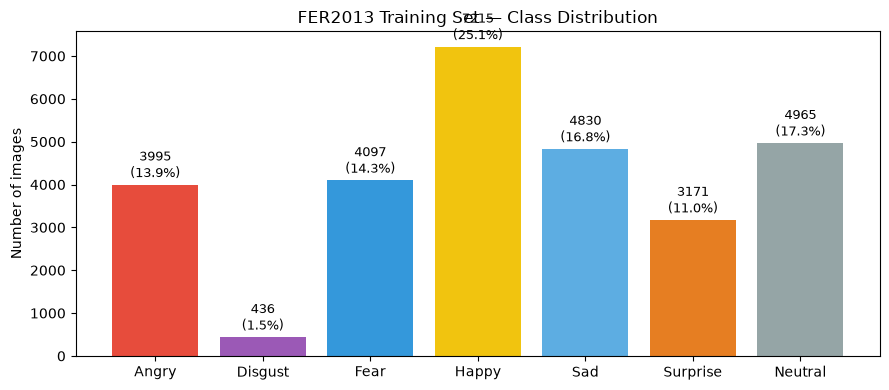

Saved: C:\Users\l.chitishvili\ml-assignment-Facial-Expression-Recognition\checkpoints\class_distribution.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

train_csv = os.path.join(DATA_DIR, 'train.csv')
df = pd.read_csv(train_csv)

counts = df['emotion'].value_counts().sort_index()
total = len(df)

print(f'Training images: {total}')
print()
for emotion_id, count in counts.items():
  label = EMOTION_LABELS[emotion_id]
  print(f'  {label:9s} {count:5d}  ({100 * count / total:5.1f}%)')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(EMOTION_LABELS, counts.values, color=['#e74c3c', '#9b59b6', '#3498db', '#f1c40f', '#5dade2', '#e67e22', '#95a5a6'])
ax.set_ylabel('Number of images')
ax.set_title('FER2013 Training Set — Class Distribution')
for i, count in enumerate(counts.values):
  ax.text(i, count + 80, f'{count}\n({100 * count / total:.1f}%)', ha='center', va='bottom', fontsize=9)
plt.tight_layout()

class_dist_path = os.path.join(CHECKPOINT_DIR, 'class_distribution.png')
plt.savefig(class_dist_path, dpi=200)
plt.show()
print(f'Saved: {class_dist_path}')


#### 2c. Log to Wandb


In [4]:
eda_run = wandb.init(
    project='fer2013-expression-recognition',
    name='class_distribution_eda',
    group='tiny',
    job_type='eda',
    dir=WANDB_DIR,
)

class_dist_table = wandb.Table(
    columns=['emotion', 'count', 'pct'],
    data=[
        [EMOTION_LABELS[emotion_id], int(counts[emotion_id]), round(100 * counts[emotion_id] / total, 2)]
        for emotion_id in sorted(counts.index)
    ],
)

wandb.log({
    'class_distribution_chart': wandb.Image(class_dist_path),
    'class_distribution_table': class_dist_table,
    'train_images_total': total,
})
wandb.finish()
print('Logged class distribution EDA to Wandb')


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\l.chitishvili\_netrc.
wandb: Currently logged in as: lchit22 (lchit22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


train_images_total,▁
train_images_total,28709


Logged class distribution EDA to Wandb


#### 3. Model Definition

In [3]:
model = TinyCNN(dropout=0.0)
dummy = torch.randn(4, 1, 48, 48)
out = model(dummy)
print(f'TinyCNN output shape: {out.shape}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')


TinyCNN output shape: torch.Size([4, 7])
Total parameters: 595,655


#### 3b. Forward and Backward Check

In [8]:
model = TinyCNN(dropout=0.0)
train_loader, _, _ = get_dataloaders(data_dir=DATA_DIR, aug_mode='none', batch_size=4)
images, labels = next(iter(train_loader))
images, labels = images.to(DEVICE), labels.to(DEVICE)

model = model.to(DEVICE)
out = model(images)
assert out.shape == (images.size(0), 7), f"Expected (batch, 7), got {out.shape}"
assert not torch.isnan(out).any() and not torch.isinf(out).any(), "Forward pass produced NaN/inf"

loss = torch.nn.functional.cross_entropy(out, labels)
model.zero_grad()
loss.backward()

bad = []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if p.grad is None:
        bad.append(f"{name}: no grad")
    elif torch.isnan(p.grad).any() or torch.isinf(p.grad).any():
        bad.append(f"{name}: NaN/inf grad")
    elif p.grad.abs().sum() == 0:
        bad.append(f"{name}: zero grad")

assert not bad, "Backward check failed:\n" + "\n".join(bad)
print(f"Forward OK: output {tuple(out.shape)}, loss={loss.item():.4f}")
print("Backward OK: gradients flow to all trainable parameters")


Forward OK: output (4, 7), loss=1.9380
Backward OK: gradients flow to all trainable parameters


#### 4. Hyperparameter Setup

In [4]:
CONFIGS = [
    # ── learning rate sweep (adam, no aug, no dropout) ──
    {'run_name': 'tiny_adam_0.01_bs64_noaug_do0',    'lr': 0.01,   'optimizer': 'adam', 'batch_size': 64, 'aug': 'none',  'dropout': 0.0, 'epochs': 15},
    {'run_name': 'tiny_adam_0.001_bs64_noaug_do0',   'lr': 0.001,  'optimizer': 'adam', 'batch_size': 64, 'aug': 'none',  'dropout': 0.0, 'epochs': 15},
    {'run_name': 'tiny_adam_0.0003_bs64_noaug_do0',  'lr': 0.0003, 'optimizer': 'adam', 'batch_size': 64, 'aug': 'none',  'dropout': 0.0, 'epochs': 15},
    {'run_name': 'tiny_adam_0.0001_bs64_noaug_do0',  'lr': 0.0001, 'optimizer': 'adam', 'batch_size': 64, 'aug': 'none',  'dropout': 0.0, 'epochs': 15},

    # ── optimizer comparison ──
    {'run_name': 'tiny_sgd_0.01_bs64_noaug_do0',     'lr': 0.01,   'optimizer': 'sgd',  'batch_size': 64, 'aug': 'none',  'dropout': 0.0, 'epochs': 15},
    {'run_name': 'tiny_sgd_0.001_bs64_noaug_do0',    'lr': 0.001,  'optimizer': 'sgd',  'batch_size': 64, 'aug': 'none',  'dropout': 0.0, 'epochs': 15},

    # ── augmentation effect ──
    {'run_name': 'tiny_adam_0.001_bs64_light_do0',   'lr': 0.001,  'optimizer': 'adam', 'batch_size': 64, 'aug': 'light', 'dropout': 0.0, 'epochs': 15},
    {'run_name': 'tiny_adam_0.001_bs64_strong_do0',  'lr': 0.001,  'optimizer': 'adam', 'batch_size': 64, 'aug': 'strong','dropout': 0.0, 'epochs': 15},

    # ── dropout effect ──
    {'run_name': 'tiny_adam_0.001_bs64_noaug_do0.25','lr': 0.001,  'optimizer': 'adam', 'batch_size': 64, 'aug': 'none',  'dropout': 0.25,'epochs': 15},
    {'run_name': 'tiny_adam_0.001_bs64_noaug_do0.5', 'lr': 0.001,  'optimizer': 'adam', 'batch_size': 64, 'aug': 'none',  'dropout': 0.5, 'epochs': 15},

    # ── batch size effect ──
    {'run_name': 'tiny_adam_0.001_bs32_noaug_do0',   'lr': 0.001,  'optimizer': 'adam', 'batch_size': 32, 'aug': 'none',  'dropout': 0.0, 'epochs': 15},
    {'run_name': 'tiny_adam_0.001_bs128_noaug_do0',  'lr': 0.001,  'optimizer': 'adam', 'batch_size': 128,'aug': 'none',  'dropout': 0.0, 'epochs': 15},
]

print(f'Total runs planned: {len(CONFIGS)}')


Total runs planned: 12


#### 5. Training

In [ ]:
import os

if "WANDB_DIR" not in globals():
    WANDB_DIR = os.path.join(os.path.expanduser("~"), "wandb_logs", "fer2013")
    os.makedirs(WANDB_DIR, exist_ok=True)

all_results = []

for i, config in enumerate(CONFIGS):
    config['arch'] = 'tiny'

    print(f'\n[{i+1}/{len(CONFIGS)}] Starting run: {config["run_name"]}')

    train_loader, val_loader, _ = get_dataloaders(
        data_dir=DATA_DIR,
        aug_mode=config['aug'],
        batch_size=config['batch_size']
    )

    model = TinyCNN(dropout=config['dropout'])

    wandb.init(
        project='fer2013-expression-recognition',
        name=config['run_name'],
        group=config['arch'],
        config=config,
        dir=WANDB_DIR,
    )

    best_val_acc = train(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        config=config,
        device=DEVICE
    )

    wandb.finish()

    all_results.append({
        'run': config['run_name'],
        'best_val_acc': best_val_acc
    })

    print(f'Done [{i+1}/{len(CONFIGS)}] — best_val_acc: {best_val_acc:.4f}')

print('\nAll TinyCNN runs complete')


In [ ]:
import json

RUN_SUPPLEMENTAL_TRAINING = True

SUPPLEMENTAL_CONFIGS = [
    {'arch': 'tiny', 'run_name': 'tiny_adam_0.001_bs32_noaug_do0_overfit',
     'lr': 0.001, 'optimizer': 'adam', 'batch_size': 32, 'aug': 'none',
     'dropout': 0.0, 'weight_decay': 0, 'scheduler': False, 'epochs': 30},
    {'arch': 'tiny', 'run_name': 'tiny_adam_0.0001_bs128_noaug_do0.5_underfit',
     'lr': 0.0001, 'optimizer': 'adam', 'batch_size': 128, 'aug': 'none',
     'dropout': 0.5, 'weight_decay': 0, 'scheduler': False, 'epochs': 5},
]

RESULTS_PATH = os.path.join(CHECKPOINT_DIR, 'tinycnn_results.json')
if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, 'r') as f:
        all_results = json.load(f)
    completed_runs = [r['run'] for r in all_results]
else:
    all_results = []
    completed_runs = []

if RUN_SUPPLEMENTAL_TRAINING:
    for i, config in enumerate(SUPPLEMENTAL_CONFIGS):
        if config['run_name'] in completed_runs:
            print(f'Skipping already done: {config["run_name"]}')
            continue

        print(f'\n[{i+1}/{len(SUPPLEMENTAL_CONFIGS)}] Starting supplemental run: {config["run_name"]}')

        train_loader, val_loader, _ = get_dataloaders(
            data_dir=DATA_DIR,
            aug_mode=config['aug'],
            batch_size=config['batch_size'],
        )

        model = TinyCNN(dropout=config['dropout'])

        wandb.init(
            project='fer2013-expression-recognition',
            name=config['run_name'],
            group=config['arch'],
            config=config,
            dir=WANDB_DIR,
        )

        best_val_acc = train(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            config=config,
            device=DEVICE,
            checkpoint_dir=CHECKPOINT_DIR,
        )
        wandb.finish()

        all_results.append({'run': config['run_name'], 'best_val_acc': best_val_acc})
        completed_runs.append(config['run_name'])
        print(f'Done — best_val_acc: {best_val_acc:.4f}')

from src.utils import load_wandb_results

wandb_results = load_wandb_results(group='tiny', run_prefix='tiny_')
export = [{'run': r['run'], 'best_val_acc': r['best_val_acc']} for r in wandb_results]

with open(RESULTS_PATH, 'w') as f:
    json.dump(export, f, indent=2)

print(f'\nSaved {len(export)} runs to {RESULTS_PATH}')
all_results = export


In [2]:
import importlib
import src.utils
importlib.reload(src.utils)
from src.utils import load_wandb_results

all_results = load_wandb_results(group='tiny', run_prefix='tiny_')


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\l.chitishvili\_netrc.


Loaded 14 runs from Wandb
tiny_adam_0.001_bs64_light_do0 | group=tiny | state=finished | best_val_acc=0.5566
tiny_adam_0.001_bs64_strong_do0 | group=tiny | state=finished | best_val_acc=0.5369
tiny_adam_0.001_bs64_noaug_do0.5 | group=tiny | state=finished | best_val_acc=0.5338
tiny_adam_0.001_bs64_noaug_do0 | group=tiny | state=finished | best_val_acc=0.5200
tiny_sgd_0.01_bs64_noaug_do0 | group=tiny | state=finished | best_val_acc=0.5186
tiny_adam_0.001_bs64_noaug_do0.25 | group=tiny | state=finished | best_val_acc=0.5165
tiny_adam_0.001_bs128_noaug_do0 | group=tiny | state=finished | best_val_acc=0.5106
tiny_adam_0.0003_bs64_noaug_do0 | group=tiny | state=finished | best_val_acc=0.5096
tiny_adam_0.001_bs32_noaug_do0_overfit | group=tiny | state=finished | best_val_acc=0.4981
tiny_adam_0.001_bs32_noaug_do0 | group=tiny | state=finished | best_val_acc=0.4972
tiny_adam_0.0001_bs64_noaug_do0 | group=tiny | state=finished | best_val_acc=0.4821
tiny_sgd_0.001_bs64_noaug_do0 | group=tiny | s

#### 6. Analysis


Using device: cuda
Loaded 14 runs from Wandb
tiny_adam_0.001_bs64_light_do0 | group=tiny | state=finished | best_val_acc=0.5566
tiny_adam_0.001_bs64_strong_do0 | group=tiny | state=finished | best_val_acc=0.5369
tiny_adam_0.001_bs64_noaug_do0.5 | group=tiny | state=finished | best_val_acc=0.5338
tiny_adam_0.001_bs64_noaug_do0 | group=tiny | state=finished | best_val_acc=0.5200
tiny_sgd_0.01_bs64_noaug_do0 | group=tiny | state=finished | best_val_acc=0.5186
tiny_adam_0.001_bs64_noaug_do0.25 | group=tiny | state=finished | best_val_acc=0.5165
tiny_adam_0.001_bs128_noaug_do0 | group=tiny | state=finished | best_val_acc=0.5106
tiny_adam_0.0003_bs64_noaug_do0 | group=tiny | state=finished | best_val_acc=0.5096
tiny_adam_0.001_bs32_noaug_do0_overfit | group=tiny | state=finished | best_val_acc=0.4981
tiny_adam_0.001_bs32_noaug_do0 | group=tiny | state=finished | best_val_acc=0.4972
tiny_adam_0.0001_bs64_noaug_do0 | group=tiny | state=finished | best_val_acc=0.4821
tiny_sgd_0.001_bs64_noaug_d

wandb: Currently logged in as: lchit22 (lchit22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


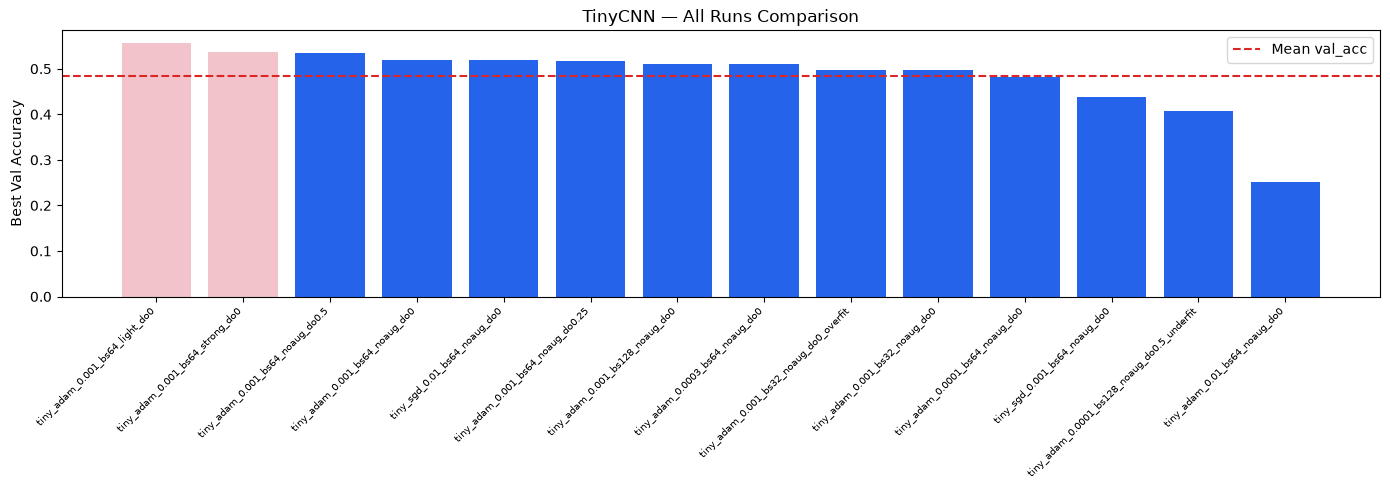

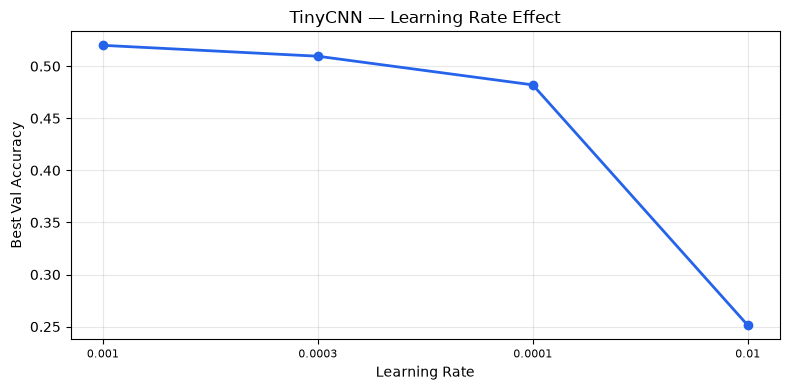

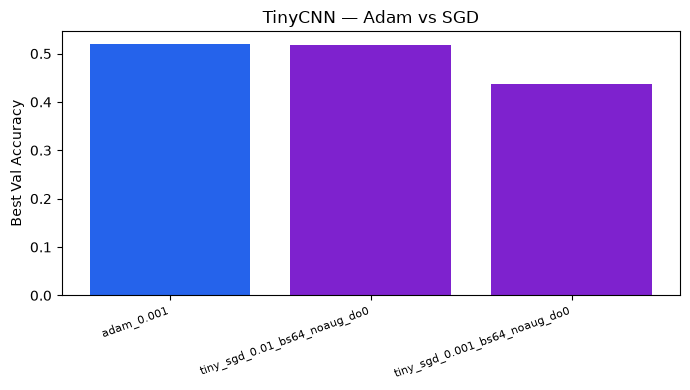

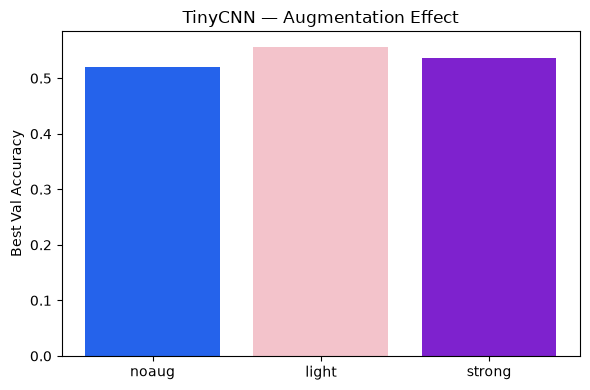

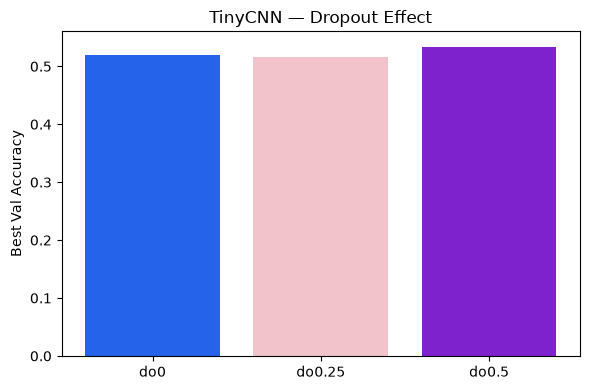


Chart 6 checkpoint: C:\Users\l.chitishvili\ml-assignment-Facial-Expression-Recognition\checkpoints\tiny_adam_0.001_bs64_light_do0_best.pt
Exists: True
Computed validation accuracy: 0.5566004876349704


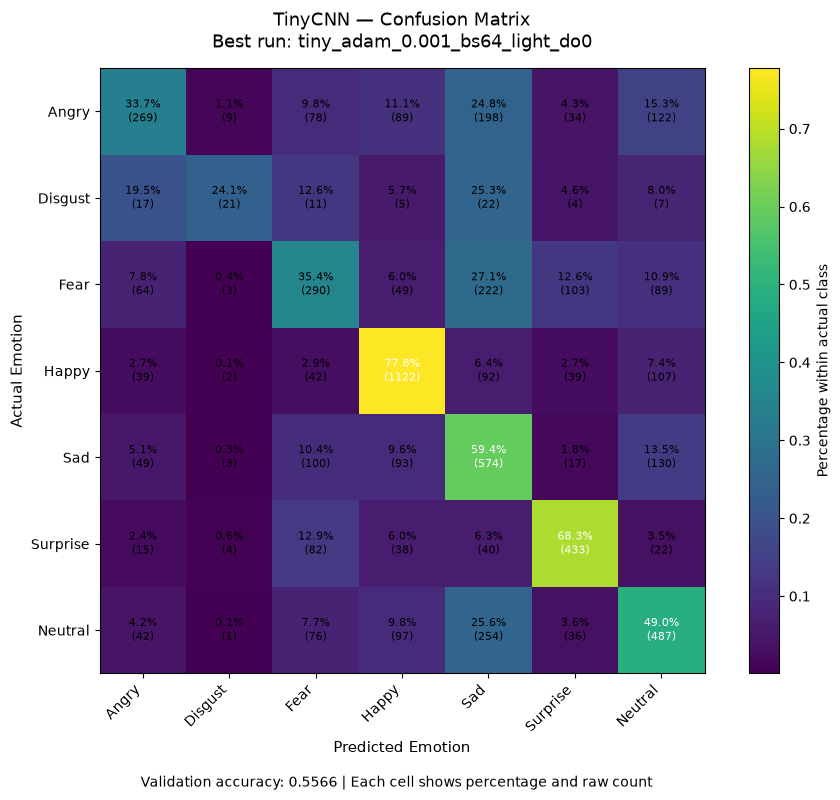

Logged Wandb built-in confusion matrix curve.
Logged custom confusion matrix chart.
Saved custom confusion matrix chart to: C:\Users\l.chitishvili\ml-assignment-Facial-Expression-Recognition\checkpoints\tinycnn_confusion_matrix_chart.png


best_val_acc,▁
computed_val_accuracy,▁
best_run_name,tiny_adam_0.001_bs64...
best_val_acc,0.5566
computed_val_accuracy,0.5566



Best run: tiny_adam_0.001_bs64_light_do0
Best val_acc: 0.5566
Logged 7/7 outputs to Wandb


In [3]:
import importlib
import os
import wandb
import torch
import pandas as pd
import matplotlib.pyplot as plt

import src.utils
importlib.reload(src.utils)

from src.dataset import get_dataloaders
from src.models import TinyCNN
from src.utils import load_wandb_results, log_tinycnn_confusion_matrix

if "CHECKPOINT_DIR" not in globals():
    CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

if "WANDB_DIR" not in globals():
    WANDB_DIR = os.path.join(os.path.expanduser("~"), "wandb_logs", "fer2013")
    os.makedirs(WANDB_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", DEVICE)

BLUE = "#2563EB"
PINK = "#F3C3CB"
PURPLE = "#7E22CE"
RED = "#DC2626"

all_results = load_wandb_results(
    group="tiny",
    run_prefix="tiny_"
)

results_df = pd.DataFrame(all_results).sort_values("best_val_acc", ascending=False)
print(results_df.to_string(index=False))

best_run_name = results_df.iloc[0]["run"]
best_val_acc = results_df.iloc[0]["best_val_acc"]

print(f"\nBest TinyCNN run: {best_run_name}")
print(f"Best val_acc: {best_val_acc:.4f}")

wandb.init(
    project="fer2013-expression-recognition",
    name="tinycnn_analysis",
    group="tiny",
    job_type="analysis",
    dir=WANDB_DIR
)

fig, ax = plt.subplots(figsize=(14, 5))

colors = [
    BLUE if "do0" in r and "noaug" in r
    else PINK if "light" in r or "strong" in r
    else PURPLE
    for r in results_df["run"]
]

ax.bar(results_df["run"], results_df["best_val_acc"], color=colors)

ax.axhline(
    y=results_df["best_val_acc"].mean(),
    color=RED,
    linestyle="--",
    label="Mean val_acc"
)

ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df["run"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Best Val Accuracy")
ax.set_title("TinyCNN — All Runs Comparison")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "tinycnn_bar.png"), dpi=200, bbox_inches="tight")
wandb.log({"tinycnn_bar_chart": wandb.Image(fig)})
plt.show()

lr_runs = [
    r for r in all_results
    if "sgd" not in r["run"]
    and "bs32" not in r["run"]
    and "bs128" not in r["run"]
    and "do0.25" not in r["run"]
    and "do0.5" not in r["run"]
    and "light" not in r["run"]
    and "strong" not in r["run"]
]

lr_df = pd.DataFrame(lr_runs)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    range(len(lr_df)),
    lr_df["best_val_acc"],
    marker="o",
    linewidth=2,
    color=BLUE
)

ax.set_xticks(range(len(lr_df)))
ax.set_xticklabels([r["run"].split("_")[2] for r in lr_runs], fontsize=8)
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Best Val Accuracy")
ax.set_title("TinyCNN — Learning Rate Effect")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "tinycnn_lr.png"), dpi=200, bbox_inches="tight")
wandb.log({"tinycnn_lr_effect": wandb.Image(fig)})
plt.show()

adam_acc = next(
    r["best_val_acc"]
    for r in all_results
    if r["run"] == "tiny_adam_0.001_bs64_noaug_do0"
)

sgd_runs = [r for r in all_results if "sgd" in r["run"]]

fig, ax = plt.subplots(figsize=(7, 4))

labels = ["adam_0.001"] + [r["run"] for r in sgd_runs]
values = [adam_acc] + [r["best_val_acc"] for r in sgd_runs]
bar_colors = [BLUE] + [PURPLE for _ in sgd_runs]

ax.bar(labels, values, color=bar_colors)

ax.set_ylabel("Best Val Accuracy")
ax.set_title("TinyCNN — Adam vs SGD")
plt.xticks(rotation=20, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "tinycnn_optimizer.png"), dpi=200, bbox_inches="tight")
wandb.log({"tinycnn_optimizer_comparison": wandb.Image(fig)})
plt.show()

aug_data = [
    ("noaug",  next(r["best_val_acc"] for r in all_results if r["run"] == "tiny_adam_0.001_bs64_noaug_do0")),
    ("light",  next(r["best_val_acc"] for r in all_results if r["run"] == "tiny_adam_0.001_bs64_light_do0")),
    ("strong", next(r["best_val_acc"] for r in all_results if r["run"] == "tiny_adam_0.001_bs64_strong_do0")),
]

aug_labels, aug_vals = zip(*aug_data)

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(aug_labels, aug_vals, color=[BLUE, PINK, PURPLE])

ax.set_ylabel("Best Val Accuracy")
ax.set_title("TinyCNN — Augmentation Effect")

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "tinycnn_augmentation.png"), dpi=200, bbox_inches="tight")
wandb.log({"tinycnn_augmentation_effect": wandb.Image(fig)})
plt.show()

dropout_data = [
    ("do0",    next(r["best_val_acc"] for r in all_results if r["run"] == "tiny_adam_0.001_bs64_noaug_do0")),
    ("do0.25", next(r["best_val_acc"] for r in all_results if r["run"] == "tiny_adam_0.001_bs64_noaug_do0.25")),
    ("do0.5",  next(r["best_val_acc"] for r in all_results if r["run"] == "tiny_adam_0.001_bs64_noaug_do0.5")),
]

do_labels, do_vals = zip(*dropout_data)

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(do_labels, do_vals, color=[BLUE, PINK, PURPLE])

ax.set_ylabel("Best Val Accuracy")
ax.set_title("TinyCNN — Dropout Effect")

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "tinycnn_dropout.png"), dpi=200, bbox_inches="tight")
wandb.log({"tinycnn_dropout_effect": wandb.Image(fig)})
plt.show()

from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

best_checkpoint = os.path.join(CHECKPOINT_DIR, f"{best_run_name}_best.pt")

print("\nChart 6 checkpoint:", best_checkpoint)
print("Exists:", os.path.exists(best_checkpoint))

if not os.path.exists(best_checkpoint):
    print("\n" + "=" * 70)
    print("CHART 6 CANNOT RUN — model checkpoint (.pt) is missing locally.")
    print("Run the training cell first to create the checkpoint.")
    print(f"Expected file: {best_checkpoint}")
    print("Then rerun this cell to get all 6 charts.")
    print("=" * 70)

else:
    # Detect dropout from best run name
    if "do0.5" in best_run_name:
        best_dropout = 0.5
    elif "do0.25" in best_run_name:
        best_dropout = 0.25
    else:
        best_dropout = 0.0

    # Load validation data
    _, val_loader, _ = get_dataloaders(
        data_dir=DATA_DIR if "DATA_DIR" in globals() else "data",
        aug_mode="none",
        batch_size=128
    )

    # Load model
    model = TinyCNN(dropout=best_dropout).to(DEVICE)
    model.load_state_dict(torch.load(best_checkpoint, map_location=DEVICE))
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    computed_val_accuracy = accuracy_score(all_labels, all_preds)
    print("Computed validation accuracy:", computed_val_accuracy)

    EMOTION_LABELS = [
        "Angry",
        "Disgust",
        "Fear",
        "Happy",
        "Sad",
        "Surprise",
        "Neutral"
    ]

    wandb.log({
        "tinycnn_confusion_matrix_curve": wandb.plot.confusion_matrix(
            y_true=all_labels,
            preds=all_preds,
            class_names=EMOTION_LABELS
        )
    })

    cm = confusion_matrix(
        all_labels,
        all_preds,
        labels=list(range(7))
    )

    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_percent = np.nan_to_num(cm_percent)

    fig, ax = plt.subplots(figsize=(10, 8))

    image = ax.imshow(cm_percent, interpolation="nearest")

    ax.set_title(
        f"TinyCNN — Confusion Matrix\nBest run: {best_run_name}",
        fontsize=13,
        pad=15
    )

    ax.set_xlabel("Predicted Emotion", fontsize=11)
    ax.set_ylabel("Actual Emotion", fontsize=11)

    ax.set_xticks(np.arange(len(EMOTION_LABELS)))
    ax.set_yticks(np.arange(len(EMOTION_LABELS)))

    ax.set_xticklabels(EMOTION_LABELS, rotation=45, ha="right")
    ax.set_yticklabels(EMOTION_LABELS)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            percent = cm_percent[i, j] * 100
            count = cm[i, j]

            text_color = "white" if cm_percent[i, j] > 0.45 else "black"

            ax.text(
                j,
                i,
                f"{percent:.1f}%\n({count})",
                ha="center",
                va="center",
                color=text_color,
                fontsize=8
            )

    cbar = fig.colorbar(image, ax=ax)
    cbar.set_label("Percentage within actual class")

    fig.text(
        0.5,
        0.01,
        f"Validation accuracy: {computed_val_accuracy:.4f} | Each cell shows percentage and raw count",
        ha="center",
        fontsize=10
    )

    plt.tight_layout(rect=[0, 0.03, 1, 1])

    confusion_path = os.path.join(CHECKPOINT_DIR, "tinycnn_confusion_matrix_chart.png")
    plt.savefig(confusion_path, dpi=200, bbox_inches="tight")

    wandb.log({
        "best_run_name": best_run_name,
        "best_val_acc": best_val_acc,
        "computed_val_accuracy": computed_val_accuracy,
        "tinycnn_confusion_matrix_chart": wandb.Image(fig)
    })

    plt.show()

    print("Logged Wandb built-in confusion matrix curve.")
    print("Logged custom confusion matrix chart.")
    print("Saved custom confusion matrix chart to:", confusion_path)

wandb.finish()

charts_logged = 7 if os.path.exists(best_checkpoint) else 5
print(f"\nBest run: {best_run_name}")
print(f"Best val_acc: {best_val_acc:.4f}")
print(f"Logged {charts_logged}/7 outputs to Wandb")
